##  **Détection DDoS : Un Système de Détection Multiclasse et Multidimensionnel avec Divers Modèles de Machine Learning**

---

###  **Aperçu du Projet**

Ce projet vise à construire un système capable de **détecter et classifier** les attaques **DDoS (Déni de Service Distribué)** en utilisant le jeu de données **CICDDoS2019**. L'objectif est de développer un modèle de **classification multiclasse** capable d'identifier différents types d'attaques DDoS à partir du trafic réseau normal. Le jeu de données comprend plusieurs types d'attaques ayant des caractéristiques de trafic réseau différentes, ce qui en fait un problème complexe pour la détection DDoS.

---

###  **Description du Jeu de Données**

Le jeu de données **CICDDoS2019**, fourni par l'Institut Canadien pour la Cybersécurité (CIC), contient des données de trafic réseau représentant plusieurs types d'attaques DDoS ainsi que du trafic bénin (non-attaque). Le jeu de données comporte plusieurs attributs comme la taille des paquets, les adresses IP source/destination et les types de protocoles. La variable cible est composée de différentes étiquettes d'attaques :

| Étiquette | Description |
|-----------|-------------|
| **Syn** | Attaque par inondation SYN |
| **Benign** | Trafic normal (non-attaque) |
| **UDP** | Attaque par inondation UDP générique |
| **MSSQL** | Attaque DDoS spécifique à MSSQL |
| **NetBIOS** | Attaque DDoS liée à NetBIOS |
| **LDAP** | Attaque basée sur le protocole LDAP |

---

###  **Aperçu du Processus**

####  **Collecte et Prétraitement des Données**

1. **Collecte des Chemins des Données** :
   - Les chemins des ensembles d'entraînement et de test sont collectés en parcourant les dossiers.
   - On s'assure que seuls les ensembles de données avec des noms correspondants sont utilisés pour l'entraînement et le test.

2. **Traitement des Données** :
   - **Mappage des Colonnes** : On mappe les noms de colonnes entre les ensembles d'entraînement et de test pour garantir leur cohérence. Les noms de colonnes dans l'ensemble de test sont renommés pour correspondre à ceux de l'ensemble d'entraînement.
   - **Gestion des Valeurs Nulles et Doublons** : On vérifie les valeurs nulles ou les doublons. Aucune valeur nulle n'est trouvée et les doublons sont supprimés.
   - **Suppression des Colonnes à Valeur Unique** : Les colonnes avec une seule valeur unique sont supprimées car elles n'apportent pas d'information utile.
   - **Suppression des Colonnes Fortement Corrélées** : Les colonnes avec un coefficient de corrélation ≥ 0,8 sont supprimées pour réduire la multicolinéarité et améliorer les performances du modèle.

---

###  **Analyse Exploratoire des Données (EDA)**

Plusieurs visualisations clés ont été réalisées pour comprendre le jeu de données :


- **Distribution de la Durée des Flux** :
   - Analyse de la durée des flux pour le trafic DDoS et normal.
- **Longueur Moyenne des Paquets par Protocole et par Attaque** :
   - Exploration de la longueur moyenne des paquets par type de protocole et par type d'attaque.
- **Distribution des Flags par Type d'Attaque** :
   - Distribution des différents types de flags par type d'attaque.
- **Distribution des Demandes par Protocole** :
   - Nombre de requêtes provenant de différents protocoles.
- **Matrice de Corrélation** :
   - Heatmap pour visualiser la matrice de corrélation et identifier les relations entre les caractéristiques.

---

###  **Prétraitement des Données et Ingénierie des Caractéristiques**

- **Division Entraînement/Test** :
   - Le jeu de données est divisé en ensembles d'entraînement, de validation et de test pour assurer une évaluation correcte du modèle.
- **Encodage des Caractéristiques** :
   - La colonne cible est encodée à l'aide de **LabelEncoder** pour convertir les étiquettes catégorielles en valeurs numériques.
- **Mise à l'Échelle des Caractéristiques** :
   - On applique la **Normalisation Min-Max** pour mettre les caractéristiques à l'échelle, améliorant ainsi les performances des algorithmes basés sur la distance.

---

###  **Entraînement et Évaluation du Modèle**

- **Sélection du Modèle** :
   - Plusieurs modèles sont entraînés et évalués pour la classification multiclasse, notamment :
     - **Forêt Aléatoire (Random Forest)**
     - **Extra Trees Classifier**
     - **XGBoost**

- **Évaluation du Modèle** :
   - On évalue les modèles à l'aide de diverses métriques comme la **précision (accuracy)**, la **précision (precision)**, le **rappel (recall)**, le **score F1** et l'**AUC ROC**.
   - Les courbes ROC sont tracées pour comparer les performances de chaque modèle à travers les différentes classes.
   - Un tableau des scores des modèles est créé et affiché pour faciliter la comparaison.

---

###  **Visualisation des Résultats**

- **Comparaison des Modèles** :
   - On trace le **score de précision (accuracy)** pour chaque modèle afin de comparer visuellement leurs performances.
   - Les courbes ROC pour tous les modèles sont tracées pour analyser leur capacité de classification, en particulier pour les tâches de classification multiclasse.

---



## 📚 Importation des Bibliothèques

In [3]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
from pathlib import Path
warnings.filterwarnings('ignore')

In [20]:
BASE = Path(r"E:\CIC-DDoS2019")
SORTIE = BASE / "echantillons"
TMP = SORTIE / "tmp"
TMP.mkdir(parents=True, exist_ok=True)

CAP = 150_000
SEED = 42
CHUNK = 100_000
LIGNES_CIBLE = 3_000_000

COLONNES_A_SUPPRIMER = [
    "Unnamed: 0", "Flow ID", "Source IP", "Source Port",
    "Destination IP", "Destination Port", "Timestamp", "SimillarHTTP",
]

COMPTES = {
    "01-12": {
        "BENIGN": 56863, "DrDoS_DNS": 5071011, "DrDoS_LDAP": 2179930,
        "DrDoS_MSSQL": 4522492, "DrDoS_NTP": 1202642, "DrDoS_NetBIOS": 4093279,
        "DrDoS_SNMP": 5159870, "DrDoS_SSDP": 2610611, "DrDoS_UDP": 3134645,
        "Syn": 1582289, "TFTP": 20082580, "UDP-lag": 366461,
    },
    "03-11": {
        "BENIGN": 56965, "LDAP": 1915122, "MSSQL": 5787453, "NetBIOS": 3657497,
        "Portmap": 186960, "Syn": 4891500, "UDP": 3754680, "UDPLag": 114348,
    },
}

HARMONISATION = {
    "DrDoS_DNS": "DNS", "DrDoS_LDAP": "LDAP", "DrDoS_MSSQL": "MSSQL",
    "DrDoS_NTP": "NTP", "DrDoS_NetBIOS": "NetBIOS", "DrDoS_SNMP": "SNMP",
    "DrDoS_SSDP": "SSDP", "DrDoS_UDP": "UDP", "UDP-lag": "UDPLag",
}


def traiter_fichier(f, journee, proba):
    tmp = TMP / f"{journee}_{f.stem}.parquet"
    if tmp.exists():
        print(f"  [{journee}] {f.name} deja traite, on saute")
        return tmp

    print(f"  [{journee}] lecture de {f.name} ...")
    morceaux = []
    for chunk in pd.read_csv(f, chunksize=CHUNK, low_memory=False):
        chunk.columns = [c.strip() for c in chunk.columns]
        chunk = chunk[chunk["Label"].isin(proba)]
        chunk = chunk.drop(columns=COLONNES_A_SUPPRIMER, errors="ignore")
        cols = [c for c in chunk.columns if c != "Label"]
        chunk[cols] = chunk[cols].apply(pd.to_numeric, errors="coerce")
        chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna()
        if chunk.empty:
            continue

        h = pd.util.hash_pandas_object(chunk, index=False).to_numpy()
        seuil = (chunk["Label"].map(proba).to_numpy() * 10_000).astype("int64")
        chunk = chunk[(h % 10_000) < seuil]

        chunk = chunk.drop_duplicates()
        chunk[cols] = chunk[cols].astype("float32")
        if len(chunk):
            morceaux.append(chunk)
        del chunk

    if not morceaux:
        return None
    df = pd.concat(morceaux, ignore_index=True)
    del morceaux
    df = df.drop_duplicates().reset_index(drop=True)
    df.to_parquet(tmp, index=False)
    print(f"      -> {len(df):,} flux uniques gardes")
    del df
    gc.collect()
    return tmp


def construire(journee):
    proba = {lab: min(1.0, LIGNES_CIBLE / n) for lab, n in COMPTES[journee].items()}

    temporaires = []
    for f in sorted((BASE / journee).rglob("*.csv")):
        t = traiter_fichier(f, journee, proba)
        if t is not None:
            temporaires.append(t)

    df = pd.concat([pd.read_parquet(t) for t in temporaires], ignore_index=True)
    df["Label"] = df["Label"].replace(HARMONISATION)

    avant = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  [{journee}] doublons supprimes : {avant - len(df):,}")

    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    df = df.groupby("Label", group_keys=False).head(CAP).reset_index(drop=True)

    df["Day"] = journee
    return df


def hash_lignes(df, colonnes):
    return pd.util.hash_pandas_object(df[colonnes], index=False)


if __name__ == "__main__":
    train = construire("01-12")
    test = construire("03-11")

    features = [c for c in train.columns if c not in ("Label", "Day") and c in test.columns]

    h_train = set(hash_lignes(train, features))
    masque = hash_lignes(test, features).isin(h_train)
    print(f"\nLignes du test identiques au train (retirees) : {masque.sum():,}")
    test = test[~masque].reset_index(drop=True)

    for nom, df in [("train_0112", train), ("test_0311", test)]:
        print(f"\n{nom} : {len(df):,} lignes, {df.shape[1]} colonnes")
        print(df["Label"].value_counts().to_string())
        df.to_parquet(SORTIE / f"{nom}.parquet", index=False)
        print(f"Enregistre : {SORTIE / (nom + '.parquet')}")

  [01-12] DrDoS_DNS.csv deja traite, on saute
  [01-12] DrDoS_LDAP.csv deja traite, on saute
  [01-12] DrDoS_MSSQL.csv deja traite, on saute
  [01-12] DrDoS_NetBIOS.csv deja traite, on saute
  [01-12] DrDoS_NTP.csv deja traite, on saute
  [01-12] DrDoS_SNMP.csv deja traite, on saute
  [01-12] DrDoS_SSDP.csv deja traite, on saute
  [01-12] DrDoS_UDP.csv deja traite, on saute
  [01-12] Syn.csv deja traite, on saute
  [01-12] TFTP.csv deja traite, on saute
  [01-12] UDPLag.csv deja traite, on saute
  [01-12] doublons supprimes : 1,655
  [03-11] LDAP.csv deja traite, on saute
  [03-11] MSSQL.csv deja traite, on saute
  [03-11] NetBIOS.csv deja traite, on saute
  [03-11] Portmap.csv deja traite, on saute
  [03-11] Syn.csv deja traite, on saute
  [03-11] UDP.csv deja traite, on saute
  [03-11] UDP_Lag.csv deja traite, on saute
  [03-11] doublons supprimes : 8,544

Lignes du test identiques au train (retirees) : 62,922

train_0112 : 1,188,497 lignes, 81 colonnes
Label
SSDP       150000
UDP   

# Chargement des fichiers

In [55]:
train_df = pd.read_parquet(r"E:\CIC-DDoS2019\echantillons\train_0112.parquet")
test_df  = pd.read_parquet(r"E:\CIC-DDoS2019\echantillons\test_0311.parquet")

In [56]:
# Supprimer la colonne Day
train_df = train_df.drop(columns=["Day"])
test_df  = test_df.drop(columns=["Day"])

In [57]:

col_name = {
'Protocol': 'Protocol',
'Timestamp': 'Timestamp',
'Flow Duration': 'Flow Duration',
'Total Fwd Packets': 'Total Fwd Packets',
'Tot Fwd Pkts': 'Total Fwd Packets',
'Total Backward Packets': 'Total Backward Packets',
'Tot Bwd Pkts': 'Total Backward Packets',
'Total Length of Fwd Packets': 'Fwd Packets Length Total',
'TotLen Fwd Pkts': 'Fwd Packets Length Total',
'Total Length of Bwd Packets': 'Bwd Packets Length Total',
'TotLen Bwd Pkts': 'Bwd Packets Length Total',
'Fwd Packet Length Max': 'Fwd Packet Length Max',
'Fwd Pkt Len Max': 'Fwd Packet Length Max',
'Fwd Packet Length Min': 'Fwd Packet Length Min',
'Fwd Pkt Len Min': 'Fwd Packet Length Min',
'Fwd Packet Length Mean': 'Fwd Packet Length Mean',
'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
'Fwd Packet Length Std': 'Fwd Packet Length Std',
'Fwd Pkt Len Std': 'Fwd Packet Length Std',
'Bwd Packet Length Max': 'Bwd Packet Length Max',
'Bwd Pkt Len Max': 'Bwd Packet Length Max',
'Bwd Packet Length Min': 'Bwd Packet Length Min',
'Bwd Pkt Len Min': 'Bwd Packet Length Min',
'Bwd Packet Length Mean': 'Bwd Packet Length Mean',
'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
'Bwd Packet Length Std': 'Bwd Packet Length Std',
'Bwd Pkt Len Std': 'Bwd Packet Length Std',
'Flow Bytes/s': 'Flow Bytes/s',
'Flow Byts/s': 'Flow Bytes/s',
'Flow Packets/s': 'Flow Packets/s',
'Flow Pkts/s': 'Flow Packets/s',
'Flow IAT Mean': 'Flow IAT Mean',
'Flow IAT Std': 'Flow IAT Std',
'Flow IAT Max': 'Flow IAT Max',
'Flow IAT Min': 'Flow IAT Min',
'Fwd IAT Total': 'Fwd IAT Total',
'Fwd IAT Tot': 'Fwd IAT Total',
'Fwd IAT Mean': 'Fwd IAT Mean',
'Fwd IAT Std': 'Fwd IAT Std',
'Fwd IAT Max': 'Fwd IAT Max',
'Fwd IAT Min': 'Fwd IAT Min',
'Bwd IAT Total': 'Bwd IAT Total',
'Bwd IAT Tot': 'Bwd IAT Total',
'Bwd IAT Mean': 'Bwd IAT Mean',
'Bwd IAT Std': 'Bwd IAT Std',
'Bwd IAT Max': 'Bwd IAT Max',
'Bwd IAT Min': 'Bwd IAT Min',
'Fwd PSH Flags': 'Fwd PSH Flags',
'Bwd PSH Flags': 'Bwd PSH Flags',
'Fwd URG Flags': 'Fwd URG Flags',
'Bwd URG Flags': 'Bwd URG Flags',
'Fwd Header Length': 'Fwd Header Length',
'Fwd Header Len': 'Fwd Header Length',
'Bwd Header Length': 'Bwd Header Length',
'Bwd Header Len': 'Bwd Header Length',
'Fwd Packets/s': 'Fwd Packets/s',
'Fwd Pkts/s': 'Fwd Packets/s',
'Bwd Packets/s': 'Bwd Packets/s',
'Bwd Pkts/s': 'Bwd Packets/s',
'Min Packet Length': 'Packet Length Min',
'Pkt Len Min': 'Packet Length Min',
'Max Packet Length': 'Packet Length Max',
'Pkt Len Max': 'Packet Length Max',
'Packet Length Mean': 'Packet Length Mean',
'Pkt Len Mean': 'Packet Length Mean',
'Packet Length Std': 'Packet Length Std',
'Pkt Len Std': 'Packet Length Std',
'Packet Length Variance': 'Packet Length Variance',
'Pkt Len Var': 'Packet Length Variance',
'FIN Flag Count': 'FIN Flag Count',
'FIN Flag Cnt': 'FIN Flag Count',
'SYN Flag Count': 'SYN Flag Count',
'SYN Flag Cnt': 'SYN Flag Count',
'RST Flag Count': 'RST Flag Count',
'RST Flag Cnt': 'RST Flag Count',
'PSH Flag Count': 'PSH Flag Count',
'PSH Flag Cnt': 'PSH Flag Count',
'ACK Flag Count': 'ACK Flag Count',
'ACK Flag Cnt': 'ACK Flag Count',
'URG Flag Count': 'URG Flag Count',
'URG Flag Cnt': 'URG Flag Count',
'CWE Flag Count': 'CWE Flag Count',
'CWE Flag Cnt': 'CWE Flag Count',
'ECE Flag Count': 'ECE Flag Count',
'ECE Flag Cnt': 'ECE Flag Count',
'Down/Up Ratio': 'Down/Up Ratio',
'Average Packet Size': 'Avg Packet Size',
'Pkt Size Avg': 'Avg Packet Size',
'Avg Fwd Segment Size': 'Avg Fwd Segment Size',
'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
'Avg Bwd Segment Size': 'Avg Bwd Segment Size',
'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
'Fwd Avg Bytes/Bulk': 'Fwd Avg Bytes/Bulk',
'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk': 'Fwd Avg Packets/Bulk',
'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate': 'Fwd Avg Bulk Rate',
'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk': 'Bwd Avg Bytes/Bulk',
'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk': 'Bwd Avg Packets/Bulk',
'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate': 'Bwd Avg Bulk Rate',
'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
'Subflow Fwd Packets': 'Subflow Fwd Packets',
'Subflow Fwd Pkts': 'Subflow Fwd Packets',
'Subflow Fwd Bytes': 'Subflow Fwd Bytes',
'Subflow Fwd Byts': 'Subflow Fwd Bytes',
'Subflow Bwd Packets': 'Subflow Bwd Packets',
'Subflow Bwd Pkts': 'Subflow Bwd Packets',
'Subflow Bwd Bytes': 'Subflow Bwd Bytes',
'Subflow Bwd Byts': 'Subflow Bwd Bytes',
'Init_Win_bytes_forward': 'Init Fwd Win Bytes',
'Init Fwd Win Byts': 'Init Fwd Win Bytes',
'Init_Win_bytes_backward': 'Init Bwd Win Bytes',
'Init Bwd Win Byts': 'Init Bwd Win Bytes',
'act_data_pkt_fwd': 'Fwd Act Data Packets',
'Fwd Act Data Pkts': 'Fwd Act Data Packets',
'min_seg_size_forward': 'Fwd Seg Size Min',
'Fwd Seg Size Min': 'Fwd Seg Size Min',
'Active Mean': 'Active Mean',
'Active Std': 'Active Std',
'Active Max': 'Active Max',
'Active Min': 'Active Min',
'Idle Mean': 'Idle Mean',
'Idle Std': 'Idle Std',
'Idle Max': 'Idle Max',
'Idle Min': 'Idle Min',
'Label': 'Label'
}


train_df.columns = train_df.columns.str.strip()
train_df.rename(columns=col_name, inplace=True)

test_df.columns = test_df.columns.str.strip()
test_df.rename(columns=col_name, inplace=True)


print(f" df : {train_df.shape}")
print(f" df : {test_df.shape}")

 df : (1188497, 80)
 df : (497409, 80)


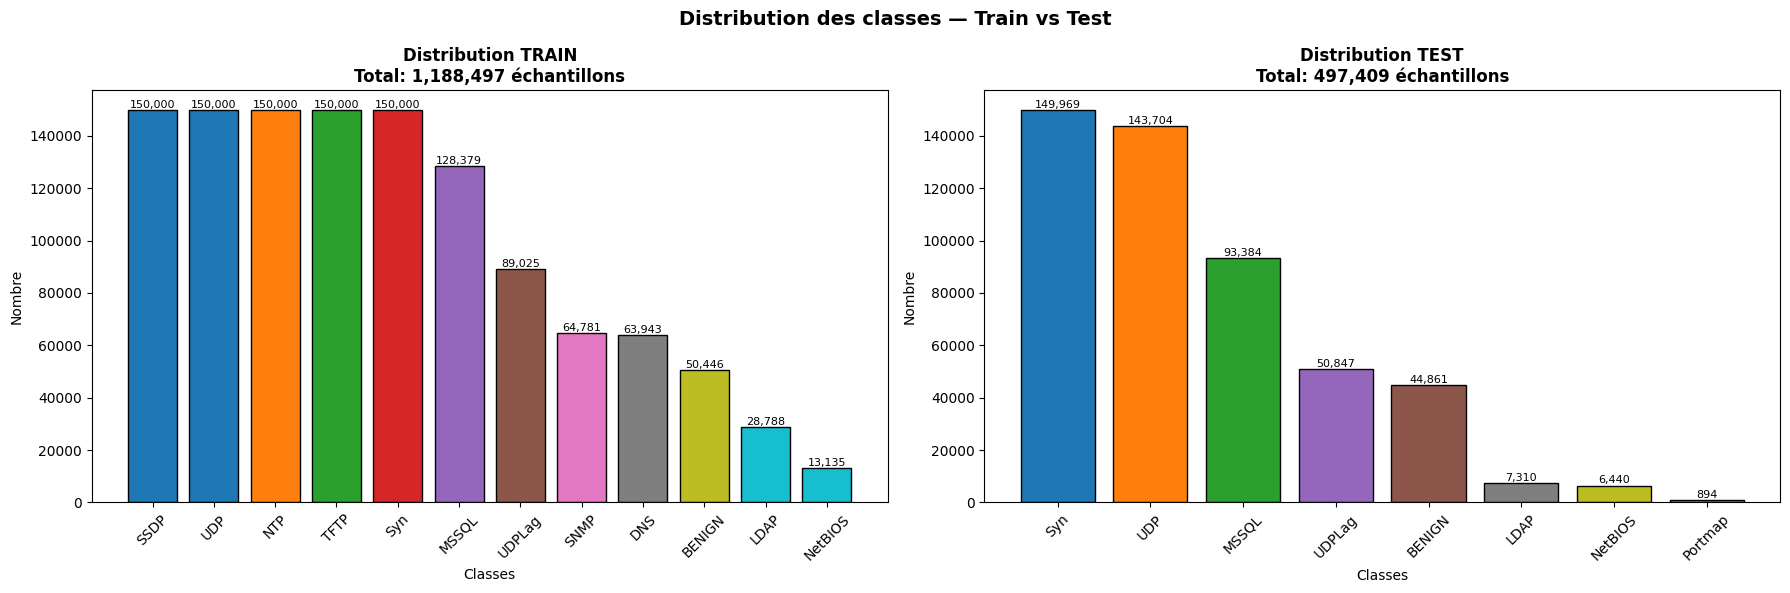

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def plot_distribution(df, ax, titre="Distribution", couleur_seed=0):
    counts = df['Label'].value_counts()
    ax.bar(
        counts.index,
        counts.values,
        color=plt.cm.tab10(np.linspace(0, 1, len(counts))),
        edgecolor='black'
    )
    ax.set_title(f'{titre}\nTotal: {len(df):,} échantillons',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Classes', fontsize=10)
    ax.set_ylabel('Nombre', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    # Ajouter les valeurs au-dessus des barres
    for i, (label, count) in enumerate(counts.items()):
        ax.text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_distribution(train_df, axes[0], titre="Distribution TRAIN")
plot_distribution(test_df,  axes[1], titre="Distribution TEST")

plt.suptitle('Distribution des classes — Train vs Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("distribution_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# appercu du fichier train
train_df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,Label
0,17.0,989365.0,20.0,0.0,7242.0,0.0,401.0,321.0,362.100006,30.127623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SSDP
1,17.0,113.0,4.0,0.0,1826.0,0.0,486.0,427.0,456.500000,34.063667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SSDP
2,17.0,1.0,2.0,0.0,1238.0,0.0,619.0,619.0,619.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,MSSQL
3,17.0,105313.0,4.0,0.0,1398.0,0.0,369.0,330.0,349.500000,22.516661,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SSDP
4,17.0,107348.0,4.0,0.0,1438.0,0.0,389.0,330.0,359.500000,34.063667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,UDP


## Data Preprocessing

In [9]:
#  les valeurs uniques et leur fréquence
for col in train_df.columns:
    print(f"\n=== {col} ===")
    print(train_df[col].value_counts().head(10))


=== Protocol ===
Protocol
17.0    937888
6.0     249412
0.0       1197
Name: count, dtype: int64

=== Flow Duration ===
Flow Duration
1.0     108410
2.0      54117
48.0     13585
47.0     10920
49.0     10361
3.0      10083
46.0      8585
50.0      6792
45.0      6381
51.0      4708
Name: count, dtype: int64

=== Total Fwd Packets ===
Total Fwd Packets
2.0      315960
4.0      276860
6.0      234836
14.0      47328
12.0      40689
8.0       38323
16.0      37417
10.0      26108
20.0      19990
200.0     19970
Name: count, dtype: int64

=== Total Backward Packets ===
Total Backward Packets
0.0     1052343
2.0       98090
4.0       18553
6.0        4428
1.0        2421
8.0        2365
3.0        2026
10.0        648
28.0        418
9.0         368
Name: count, dtype: int64

=== Fwd Packets Length Total ===
Fwd Packets Length Total
0.0        234783
2088.0     134738
2064.0      77909
1398.0      66112
1438.0      65828
3096.0      45518
2944.0      26155
88000.0     19568
7242.0      14

In [10]:
# Afficher les colonnes avec une seule valeur unique
for i in train_df.columns:
    if train_df[i].nunique() == 1:
        print(i)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


In [58]:
# Supprimer la colonne dupliquée
if 'Fwd Header Length.1' in train_df.columns:
    train_df = train_df.drop(columns=['Fwd Header Length.1'])
    print("Colonne 'Fwd Header Length.1' supprimée de train")

if 'Fwd Header Length.1' in test_df.columns:
    test_df = test_df.drop(columns=['Fwd Header Length.1'])
    print("Colonne 'Fwd Header Length.1' supprimée de test")

print(f"\nTrain : {train_df.shape}")
print(f"Test  : {test_df.shape}")

Colonne 'Fwd Header Length.1' supprimée de train
Colonne 'Fwd Header Length.1' supprimée de test

Train : (1188497, 79)
Test  : (497409, 79)


In [12]:
# Trouver les colonnes avec une seule valeur unique
colonnes_valeur_unique = [col for col in train_df.columns if train_df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur : {colonnes_valeur_unique}")
#Supprimer les colonnes à valeur unique
train_df = train_df.drop(columns=colonnes_valeur_unique)
test_df = test_df.drop(columns=colonnes_valeur_unique)

Colonnes avec une seule valeur : ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


#### Identifier les colonnes catégorielles, les colonnes numériques

In [13]:
SEUIL = 10

cat_cols = ([col for col in train_df.columns if train_df[col].dtypes == "O"] +
            [col for col in train_df.columns if train_df[col].nunique() < SEUIL and train_df[col].dtypes != "O"])

num_cols = [col for col in train_df.columns if train_df[col].dtypes != "O" and train_df[col].nunique() >= SEUIL]

print(f"Catégorielles : {len(cat_cols)}")
print(f"Numériques   : {len(num_cols)}")

Catégorielles : 8
Numériques   : 59


# valeurs infinie

In [14]:
# analyse des valeurs infinies
np.isinf(train_df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

### valeurs manquantes

In [15]:
# Nombre total de valeurs manquantes
train_df.isnull().sum().sum()


np.int64(0)

### Lignes dupliquées

In [16]:
print(f" Nombre de lignes dupliquées : {train_df.duplicated().sum()}")

 Nombre de lignes dupliquées : 0


In [17]:
# Vérifier rapidement les négatifs
neg_cols = [col for col in train_df.select_dtypes(include=[np.number]).columns if (train_df[col] < 0).sum() > 0]
print(f"Colonnes avec négatifs: {neg_cols}")
print(f"Total négatifs: {sum((train_df[col] < 0).sum() for col in train_df.select_dtypes(include=[np.number]).columns):,}")

Colonnes avec négatifs: ['Fwd Header Length', 'Bwd Header Length', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min']
Total négatifs: 2,302,285


In [18]:
for col in ['Fwd Header Length', 'Bwd Header Length', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min']:
    if col in train_df.columns:
        print(f"{col:25s} : {train_df[col].nunique():>6,} valeurs uniques, {(train_df[col] < 0).sum():>6,} négatifs")

Fwd Header Length         :  4,634 valeurs uniques, 126,308 négatifs
Bwd Header Length         :    591 valeurs uniques,    197 négatifs
Init Fwd Win Bytes        :    936 valeurs uniques, 939,085 négatifs
Init Bwd Win Bytes        :    920 valeurs uniques, 1,073,611 négatifs
Fwd Seg Size Min          :  1,399 valeurs uniques, 163,084 négatifs


In [19]:
def traitement_negative_values(df, verbose=False):
    # -1 → 0
    for col in ['Init Fwd Win Bytes', 'Init Bwd Win Bytes']:
        if col in df.columns:
            df.loc[df[col] == -1, col] = 0

    # Négatifs → médiane
    for col in ['Fwd Header Length', 'Bwd Header Length', 'Fwd Seg Size Min']:
        if col in df.columns:
            median_val = df[col][df[col] >= 0].median()
            df.loc[df[col] < 0, col] = median_val

    if verbose:
        cols =['Fwd Header Length', 'Bwd Header Length', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min']
        total = sum((df[col] < 0).sum() for col in cols if col in df.columns)
        print(f"Négatifs restants: {total:,}")

    return df
train_df = traitement_negative_values(train_df, verbose=True)
test_df  = traitement_negative_values(test_df,  verbose=True) 

Négatifs restants: 0
Négatifs restants: 0


# Exploratory Data Analysis (EDA)


### Colonnes catégorielles


 Statistiques de Label :
Label
SSDP       150000
UDP        150000
NTP        150000
TFTP       150000
Syn        150000
MSSQL      128379
UDPLag      89025
SNMP        64781
DNS         63943
BENIGN      50446
LDAP        28788
NetBIOS     13135
Name: count, dtype: int64

Pourcentage :
Label
SSDP       12.620983
UDP        12.620983
NTP        12.620983
TFTP       12.620983
Syn        12.620983
MSSQL      10.801794
UDPLag      7.490553
SNMP        5.450666
DNS         5.380157
BENIGN      4.244521
LDAP        2.422219
NetBIOS     1.105177
Name: proportion, dtype: float64


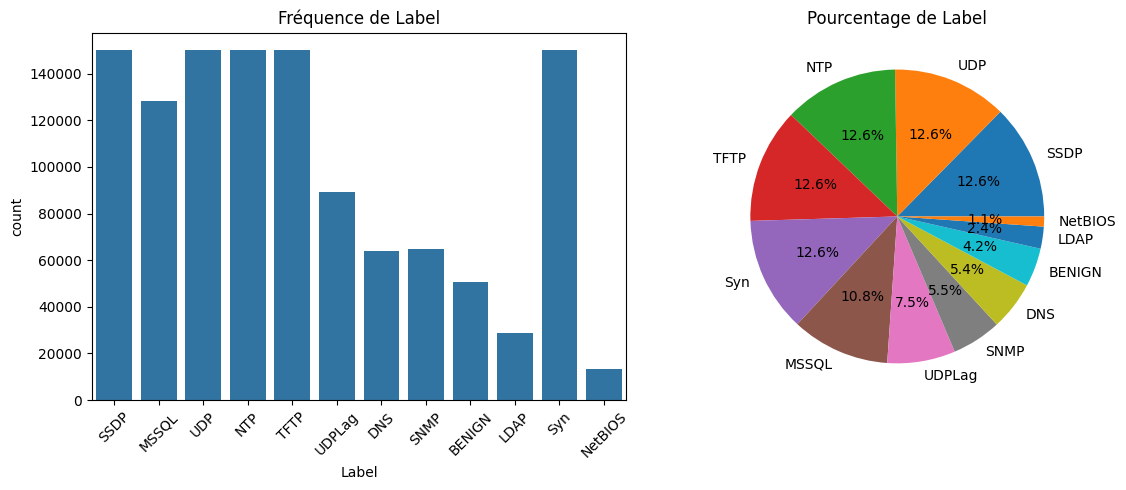

In [20]:
def analyser_colonne_cat(donnees, colonne):

    # Afficher les statistiques
    print(f"\n Statistiques de {colonne} :")
    print(donnees[colonne].value_counts())
    print("\nPourcentage :")
    print(donnees[colonne].value_counts(normalize=True) * 100)

    # Afficher les graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Diagramme à barres
    sns.countplot(x=colonne, data=donnees, ax=axes[0])
    axes[0].set_title(f'Fréquence de {colonne}')
    axes[0].tick_params(axis='x', rotation=45)

    # Diagramme circulaire
    valeurs = donnees[colonne].value_counts()
    axes[1].pie(valeurs, labels=valeurs.index, autopct='%1.1f%%')
    axes[1].set_title(f'Pourcentage de {colonne}')

    plt.tight_layout()
    plt.show()

analyser_colonne_cat(train_df, 'Label')

# Analyser toutes les colonnes catégorielles
#for col in cat_cols:
    #analyser_colonne_cat(train_df, col)

for col in train_df.columns:
    if col != 'Label' and train_df[col].dtype in ['int64', 'float32']:
        print(f'ANALYSE DE {col}')
        print(train_df.groupby('Label')[col].mean().sort_values(ascending=False))

Afin de compléter notre analyse exploratoire et d'identifier de façon rigoureuse les variables les plus pertinentes pour la classification, nous allons appliquer la méthode de la Mutual Information. Contrairement à la corrélation de Pearson qui ne capture que les relations linéaires, la Mutual Information mesure toute forme de dépendance entre une variable et le label, qu'elle soit linéaire ou non. Pour chaque variable, elle répond à la question suivante : est-ce que connaître la valeur de cette variable me permet de mieux prédire la classe du flux réseau ? Un score de zéro signifie que la variable n'apporte aucune information sur le label, et plus le score est élevé, plus la variable est discriminante. Nous allons ainsi obtenir un classement objectif des 15 meilleures variables de notre dataset."

In [21]:
def plot_boxplot(variable, df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Label", y=variable, data=df)
    plt.yscale('log')
    plt.title(f"Distribution de {variable}", fontsize=14, fontweight='bold')
    plt.xlabel("Type de trafic")
    plt.ylabel(variable)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

###  Flow Duration = Le temps total pendant lequel un flux réseau a été actif (du premier paquet au dernier paquet)

In [22]:
stats_secondes = train_df.groupby('Label')['Flow Duration'].describe()
stats_secondes

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,50446.0,1.010432e+07,3.001009e+07,1.0,20604.0,21013.5,1.131298e+05,119998744.0
DNS,63943.0,6.098193e+04,1.461645e+06,1.0,2.0,25.0,8.300000e+01,120000000.0
LDAP,28788.0,3.558640e+04,5.059588e+05,1.0,2.0,41.0,6.500000e+01,11166178.0
MSSQL,128379.0,1.545173e+05,1.360409e+06,1.0,1.0,2.0,4.600000e+01,119151080.0
NTP,150000.0,1.821504e+04,5.829895e+05,1.0,452.0,1141.0,4.712000e+03,119999880.0
NetBIOS,13135.0,6.563661e+06,1.591304e+07,1.0,1.0,47.0,1.845000e+02,119708368.0
SNMP,64781.0,9.655551e+04,2.715654e+06,1.0,1.0,2.0,3.200000e+01,119999984.0
SSDP,150000.0,1.912865e+05,3.371193e+05,1.0,107019.0,210953.0,2.166810e+05,71974256.0
Syn,150000.0,8.228118e+07,3.607418e+07,1.0,82116260.0,96359380.0,1.043703e+08,119999656.0


In [23]:
#duree= test_df.groupby('Label')['Flow Duration'].describe()
#duree

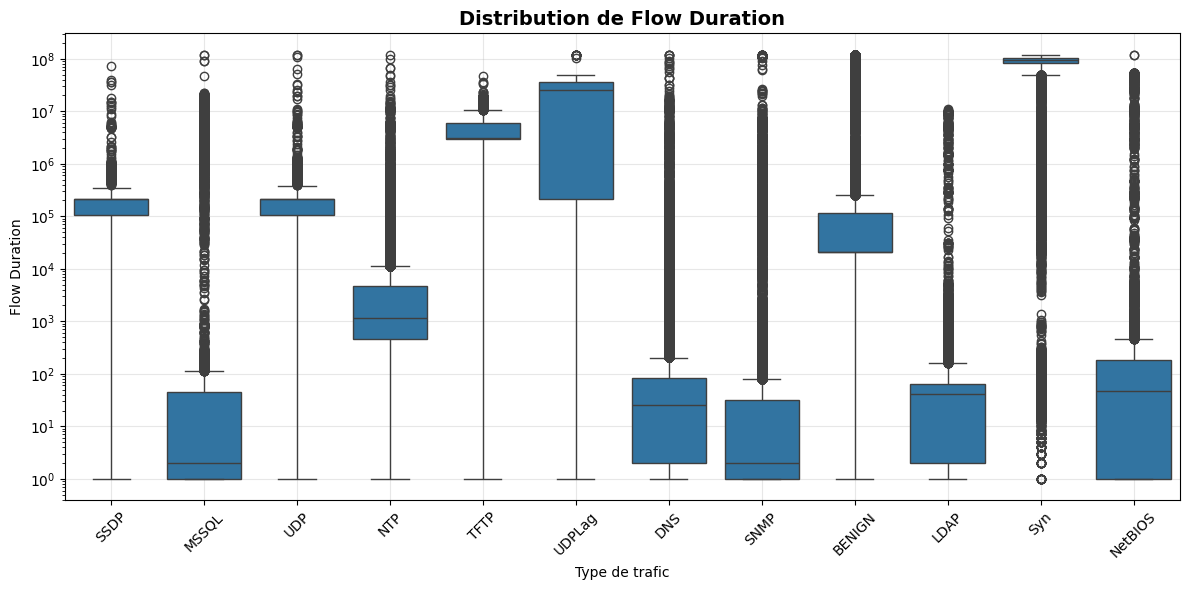

In [24]:
plot_boxplot('Flow Duration', train_df)

# analyse de la taille moyenne des paquets par type de trafic : Taille Moyenne des Paquets

In [25]:
AvgPacketSize = train_df.groupby('Label')['Avg Fwd Segment Size'].describe()
AvgPacketSize

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,50446.0,44.398853,94.358200,0.0,0.000000,31.0,43.0,3015.290527
DNS,63943.0,826.197632,517.649170,0.0,421.000000,673.0,1432.0,1472.000000
LDAP,28788.0,1392.816162,208.574905,0.0,1424.000000,1464.0,1472.0,1472.000000
MSSQL,128379.0,609.885193,232.916275,0.0,451.000000,539.0,673.0,1472.000000
NTP,150000.0,428.967773,31.718668,0.0,429.714294,440.0,440.0,1017.000000
NetBIOS,13135.0,390.302551,252.586243,0.0,229.000000,265.0,506.0,1472.000000
SNMP,64781.0,1320.483398,226.773590,0.0,1300.000000,1372.0,1424.0,1472.000000
SSDP,150000.0,359.568939,73.774620,0.0,348.000000,349.5,359.5,1472.000000
Syn,150000.0,0.125222,11.182950,0.0,0.000000,0.0,0.0,1472.000000


In [26]:
#plot_boxplot('Avg Packet Size', train_df)

# Fwd Packets Length Total :le volume total d'octets envoyés dans un flux réseau, du client vers le serveur.

In [27]:
#FwdPacketsLengthTotal = train_df.groupby('Label')['Fwd Packets Length Total'].describe()
#FwdPacketsLengthTotal

In [28]:
#plot_boxplot('Fwd Packets Length Total', train_df)

# Fwd Packets/s : C'est le rythme d'envoi des paquets, combien de paquets partent vers la victime chaque seconde.

In [29]:
FwdPackets = train_df.groupby('Label')['Fwd Packets/s'].describe()
FwdPackets


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,50446.0,4.205641e+04,250745.312500,0.008480,22.976818,95.670891,9.718173e+01,3000000.00
DNS,63943.0,6.747226e+05,805172.437500,0.039297,25974.025391,80000.000000,1.000000e+06,2000000.00
LDAP,28788.0,5.873961e+05,780039.000000,0.325307,36363.636719,51282.050781,1.000000e+06,2000000.00
MSSQL,128379.0,1.113755e+06,865267.750000,0.043772,43478.261719,1000000.000000,2.000000e+06,2000000.00
NTP,150000.0,7.207068e+04,104474.953125,0.030518,9951.707764,37043.898438,1.119523e+05,4000000.00
NetBIOS,13135.0,6.523048e+05,847179.187500,0.053863,19230.769531,43478.261719,2.000000e+06,2666666.75
SNMP,64781.0,1.080779e+06,805516.750000,0.053434,64516.128906,1000000.000000,2.000000e+06,3000000.00
SSDP,150000.0,1.700079e+04,155968.828125,0.055575,27.692009,28.490840,3.741333e+01,4000000.00
Syn,150000.0,1.385902e+03,24081.632812,0.034732,0.128003,0.145068,1.653382e-01,2000000.00


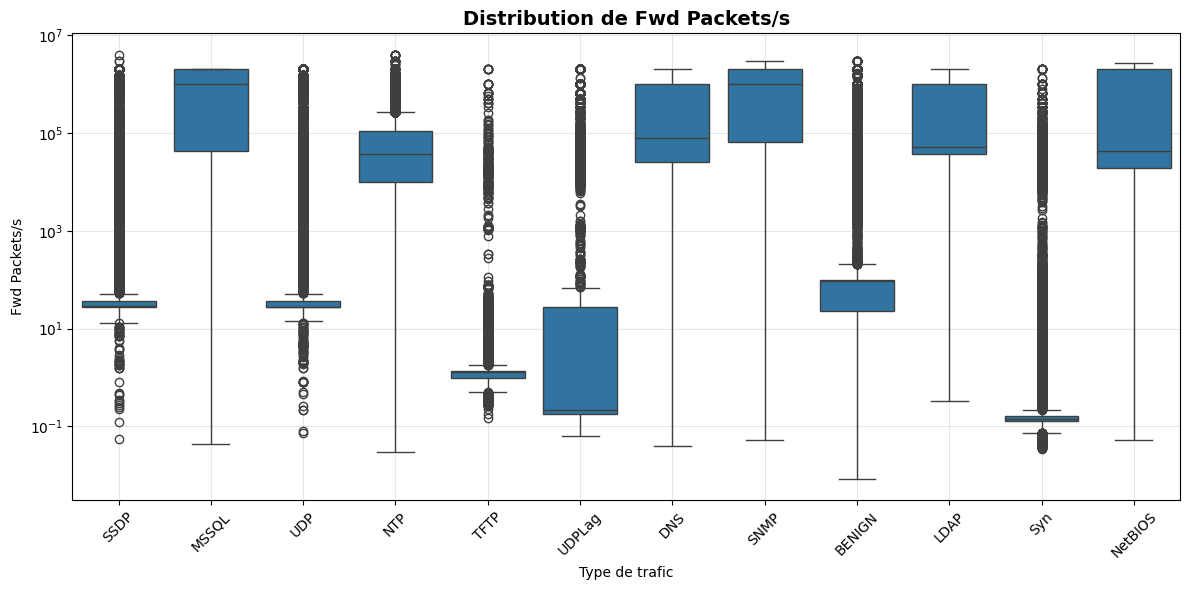

In [30]:
plot_boxplot('Fwd Packets/s', train_df)


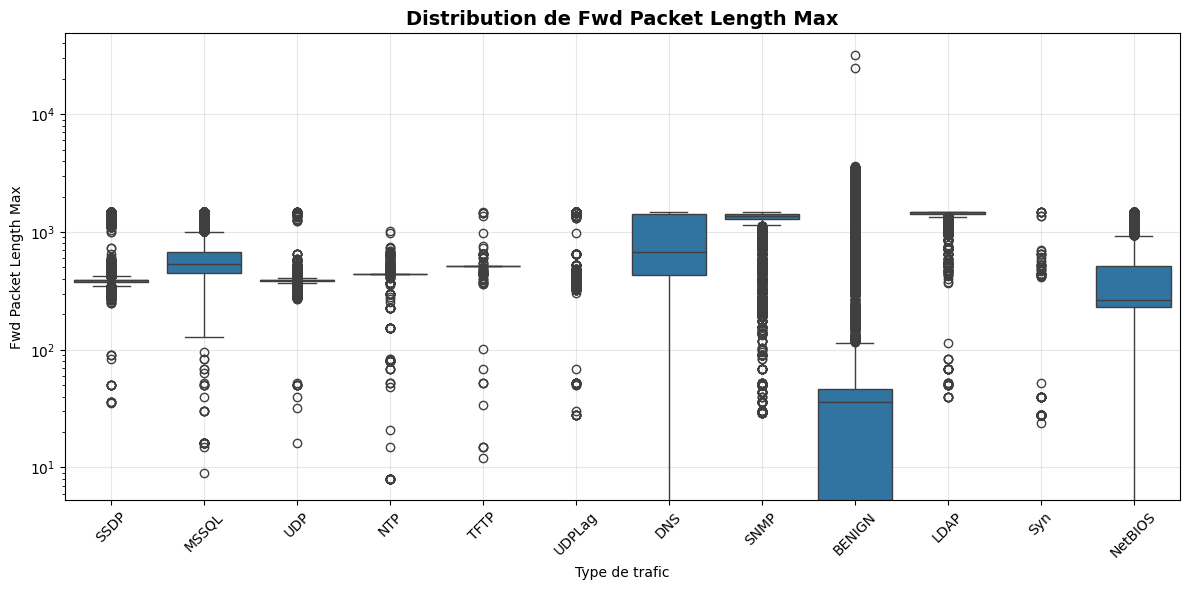

In [31]:
plot_boxplot('Fwd Packet Length Max', train_df)


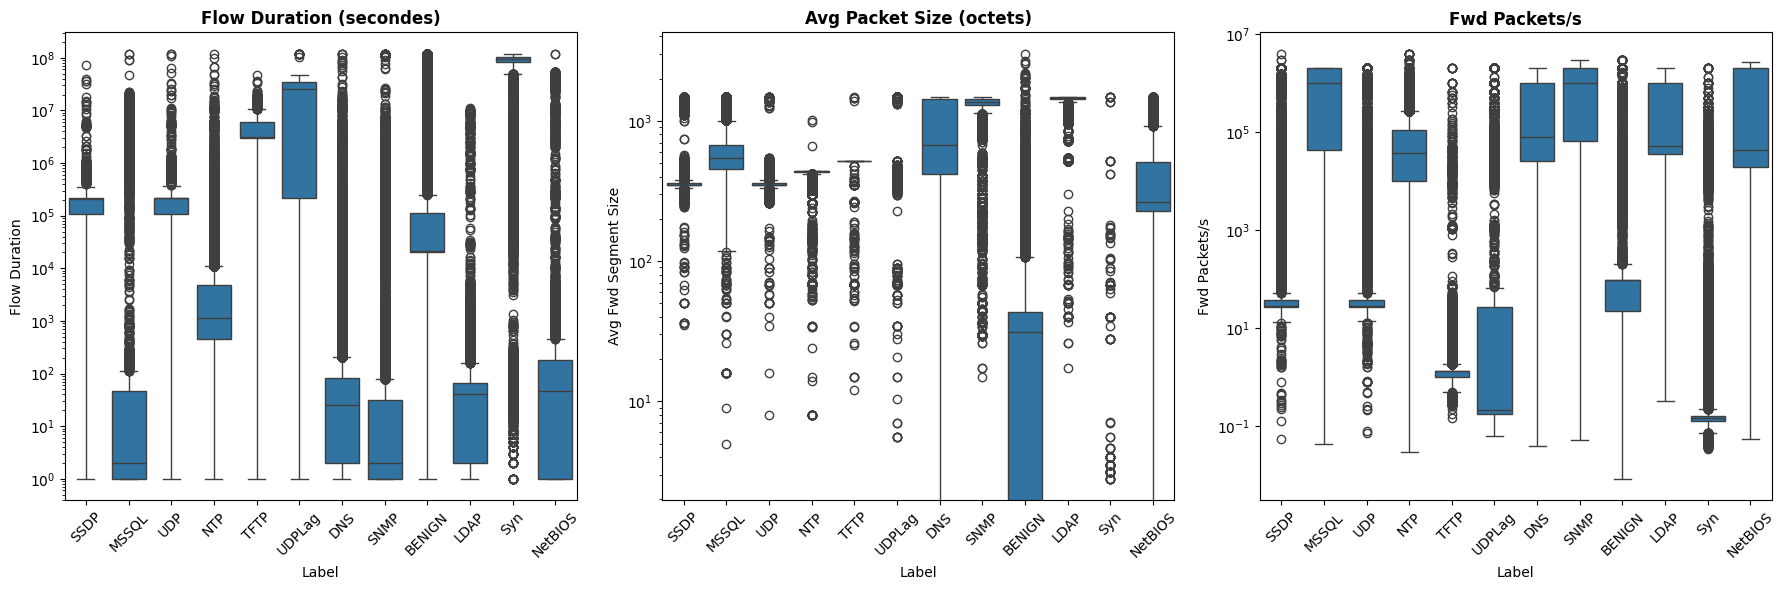

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Flow Duration
sns.boxplot(x='Label', y='Flow Duration', data=train_df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration (secondes)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 2. Avg Packet Size
sns.boxplot(x='Label', y='Avg Fwd Segment Size', data=train_df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Avg Packet Size (octets)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# 3. Fwd Packets/s
sns.boxplot(x='Label', y='Fwd Packets/s', data=train_df, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('Fwd Packets/s', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Ajouter les ports
#port_mapping = {
#   'LDAP': 389, 'MSSQL': 1434, 'NetBIOS': 137,
#  'DNS': 53, 'UDP': 53, 'Syn': 80, 'BENIGN': 0
#}

#train_df['Dst Port'] = train_df['Label'].map(port_mapping).fillna(0)
#test_df['Dst Port'] = test_df['Label'].map(port_mapping).fillna(0)


### Indicateurs de paquets et motifs d'attaque

MOYENNE DES FLAGS PAR TYPE D'ATTAQUE
         SYN Flag Count  ACK Flag Count
Label                                  
BENIGN         0.001368        0.190758
DNS            0.000407        0.003644
LDAP           0.001806        0.005245
MSSQL          0.000008        0.000872
NTP            0.000000        0.001360
NetBIOS        0.000000        0.025200
SNMP           0.000741        0.005125
SSDP           0.000007        0.000193
Syn            0.000087        0.999267
TFTP           0.000007        0.002687
UDP            0.000107        0.000507
UDPLag         0.000067        0.754653


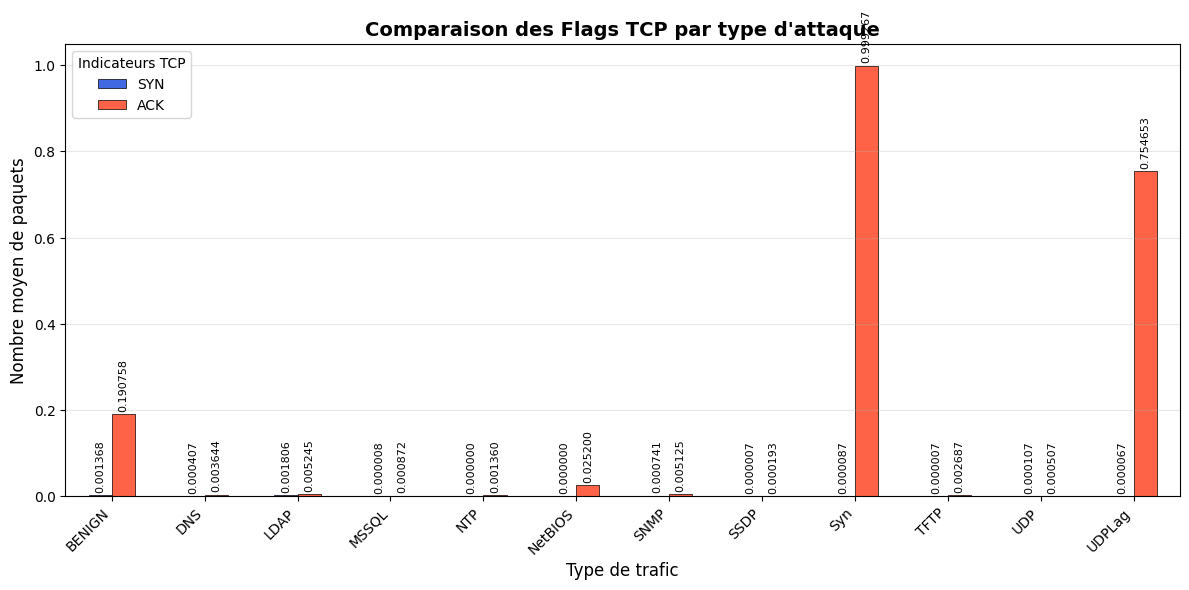

In [34]:
stats = train_df.groupby('Label')[['SYN Flag Count', 'ACK Flag Count']].mean()
print("="*50)
print("MOYENNE DES FLAGS PAR TYPE D'ATTAQUE")
print("="*50)
print(stats)

# Graphique
ax = stats.plot(kind='bar', figsize=(12, 6), color=['royalblue', 'tomato'], edgecolor='black', linewidth=0.5)

plt.title("Comparaison des Flags TCP par type d'attaque", fontsize=14, fontweight='bold')
plt.ylabel("Nombre moyen de paquets", fontsize=12)
plt.xlabel("Type de trafic", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Indicateurs TCP", labels=['SYN', 'ACK'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', fontsize=8, rotation=90, padding=2)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
mask = train_df['Label'] == 'Syn'
train_df.loc[mask, ['SYN Flag Count', 'ACK Flag Count']] = train_df.loc[mask, ['ACK Flag Count', 'SYN Flag Count']].values

### Analyse des requêtes provenant de différents protocoles

Tableau croisé : Protocole vs Attaque
Protocol  0.0     6.0     17.0
Label                         
BENIGN     867   28542   21037
DNS        119     670   63154
LDAP        64     304   28420
MSSQL       23     267  128089
NTP         22     446  149532
NetBIOS     12     514   12609
SNMP        60     620   64101
SSDP         2      63  149935
Syn          3  149967      30
TFTP         3     505  149492
UDP          9     143  149848
UDPLag      13   67371   21641


<Figure size 1200x600 with 0 Axes>

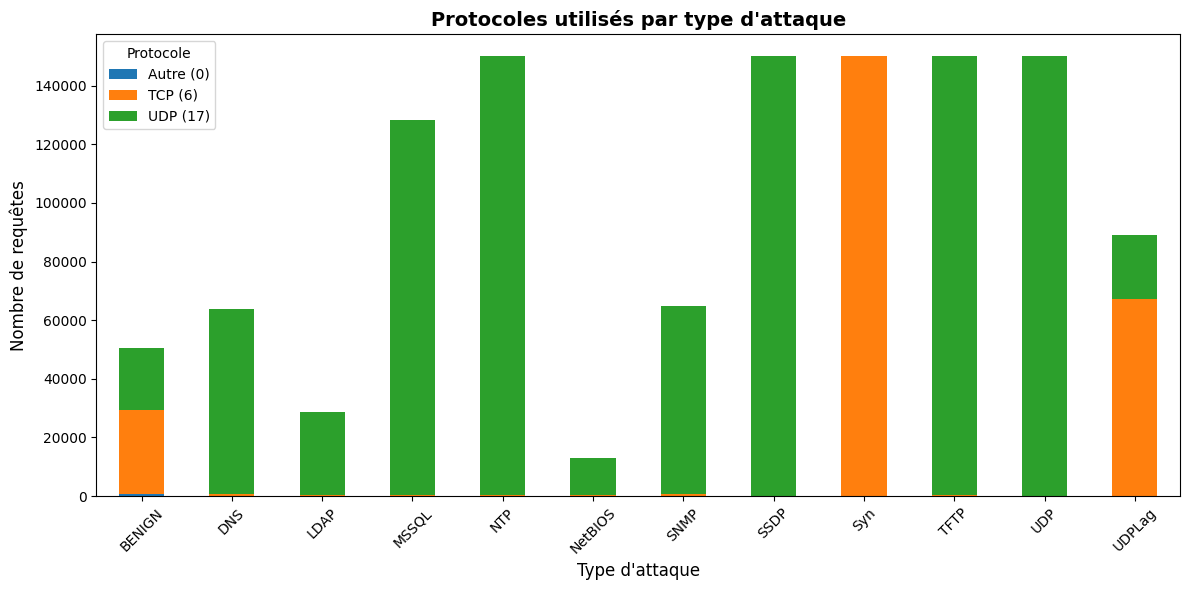

In [36]:
# Créer un tableau
tableau_croise = pd.crosstab(train_df['Label'], train_df['Protocol'])
print("Tableau croisé : Protocole vs Attaque")
print(tableau_croise)
plt.figure(figsize=(12, 6))

# Créer un graphique à barres
tableau_croise.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Protocoles utilisés par type d'attaque", fontsize=14, fontweight='bold')
plt.xlabel("Type d'attaque", fontsize=12)
plt.ylabel("Nombre de requêtes", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Protocole", labels=['Autre (0)', 'TCP (6)', 'UDP (17)'])
plt.tight_layout()
plt.show()


   Train: 1197 lignes supprimées
   Train: [np.float32(6.0), np.float32(17.0)]
Protocol    6.0     17.0
Label                   
BENIGN     28542   21037
DNS          670   63154
LDAP         304   28420
MSSQL        267  128089
NTP          446  149532
NetBIOS      514   12609
SNMP         620   64101
SSDP          63  149935
Syn       149967      30
TFTP         505  149492
UDP          143  149848
UDPLag     67371   21641


<Figure size 1200x600 with 0 Axes>

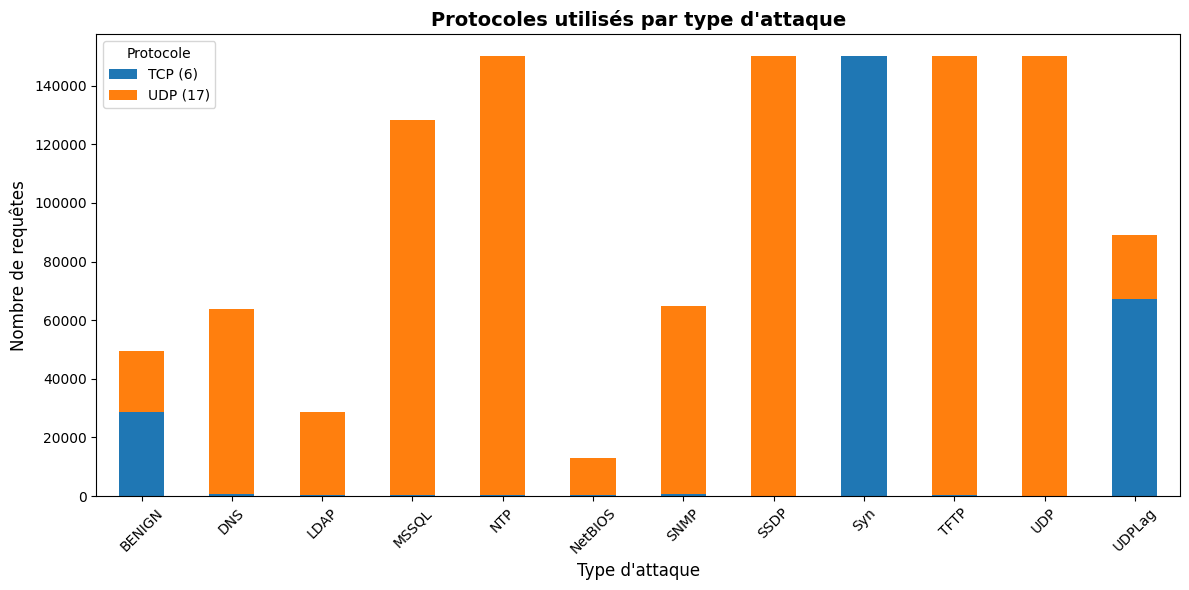

In [37]:

# Train
train_before = len(train_df)
train_df = train_df[train_df['Protocol'] != 0]
train_removed = train_before - len(train_df)
print(f"   Train: {train_removed} lignes supprimées")

print(f"   Train: {sorted(train_df['Protocol'].unique())}")


tableau_croise = pd.crosstab(train_df['Label'], train_df['Protocol'])
print(tableau_croise)

plt.figure(figsize=(12, 6))
tableau_croise.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Protocoles utilisés par type d'attaque", fontsize=14, fontweight='bold')
plt.xlabel("Type d'attaque", fontsize=12)
plt.ylabel("Nombre de requêtes", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Protocole", labels=['TCP (6)', 'UDP (17)'])
plt.tight_layout()
plt.show()


In [38]:
# --- TRAIN ---
num_cols_train = [c for c in num_cols if c in train_df.columns and c != 'Label']
cat_cols_train = [c for c in cat_cols if c in train_df.columns and c != 'Label']
cat_cols_train.append('Label')

for col in num_cols_train:
    train_df[col] = train_df[col].astype('float32')

for col in cat_cols_train:
    train_df[col] = train_df[col].astype('category')

# --- TEST ---
num_cols_test = [c for c in num_cols if c in test_df.columns and c != 'Label']
cat_cols_test = [c for c in cat_cols if c in test_df.columns and c != 'Label']
cat_cols_test.append('Label')

for col in num_cols_test:
    test_df[col] = test_df[col].astype('float32')

for col in cat_cols_test:
    test_df[col] = test_df[col].astype('category')



### Sélection des Caractéristiques

In [39]:
#  Sélectionner uniquement les colonnes numériques
colonnes_numeriques = train_df.select_dtypes(include=[np.number])
# Calculer la matrice de corrélation
matrice_correlation = colonnes_numeriques.corr().abs()
# Créer un masque pour la partie supérieure de la matrice (corr(A,B) = corr(B,A))
masque = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)

triangle_superieur = matrice_correlation.where(masque)
# Trouver les colonnes avec une corrélation >= 0.8
colonnes_fortement_correlees = [
    col for col in triangle_superieur.columns
    if any(triangle_superieur[col] > 0.95)
]
# Afficher les résultats
print(f"Nombre total de colonnes fortement corrélées : {len(colonnes_fortement_correlees)}")
print("Colonnes fortement corrélées :", colonnes_fortement_correlees)

Nombre total de colonnes fortement corrélées : 26
Colonnes fortement corrélées : ['Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Act Data Packets', 'Idle Mean', 'Idle Max', 'Idle Min']


In [40]:
# suppression des colonnes fortement corrélées dans train et test
train_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)
test_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)

In [41]:
for col in cat_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].astype('category')
train_df.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,...,Packet Length Variance,Down/Up Ratio,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Std
count,1187300.0,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,...,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06,1.187300e+06
mean,13152137.0,1.477564e+01,5.152143e-01,5.750683e+03,2.421324e+02,4.539319e+02,1.359559e+01,1.579449e+01,1.863212e+00,4.993935e+00,...,3.595439e+03,5.427356e-02,1.458668e+03,1.749666e+02,1.279506e+02,8.366627e+03,7.910302e+03,2.069670e+04,4.273569e+03,8.370104e+05
std,30753780.0,3.468772e+01,9.274338e+00,2.272515e+04,2.591305e+04,3.869600e+02,3.504271e+01,2.477801e+02,1.716739e+01,5.678725e+01,...,1.190778e+05,3.095082e-01,4.766105e+03,2.518809e+03,3.003786e+02,1.529346e+05,1.118697e+05,2.693405e+05,1.372563e+05,2.548780e+06
min,1.0,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,130.0,2.000000e+00,0.000000e+00,8.340000e+02,0.000000e+00,3.690000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,108049.0,4.000000e+00,0.000000e+00,2.064000e+03,0.000000e+00,4.020000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3008937.0,1.000000e+01,0.000000e+00,2.874000e+03,0.000000e+00,5.160000e+02,2.485692e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,8.848095e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,119999656.0,5.063000e+03,4.602000e+03,1.526642e+07,1.099376e+07,3.212000e+04,2.221556e+03,3.796000e+04,1.460000e+03,5.011060e+03,...,4.377889e+07,2.300000e+01,6.553500e+04,6.553500e+04,1.480000e+03,1.605015e+07,1.220898e+07,1.941638e+07,1.605015e+07,5.727196e+07


In [42]:
print(f" df : {train_df.shape}")
print(f" df : {test_df.shape}")

 df : (1187300, 41)
 df : (497409, 41)


In [59]:
train = train_df
test = test_df

print(f"Train brut : {len(train):,} lignes")
print(f"Test brut  : {len(test):,} lignes")

Train brut : 1,188,497 lignes
Test brut  : 497,409 lignes


### Division en ensembles d'entraînement, validation et test


In [60]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path
from time import time

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, roc_auc_score
)
from xgboost import XGBClassifier

SORTIE = Path(r"E:\CIC-DDoS2019\echantillons")
SEED = 42

CLASSES_COMMUNES = [
    "BENIGN", "LDAP", "MSSQL", "NetBIOS", "Syn", "UDP", "UDPLag"
]

train = train_df.copy()
test = test_df.copy()

print(f"Train brut : {len(train):,} lignes")
print(f"Test brut  : {len(test):,} lignes")


Train brut : 1,188,497 lignes
Test brut  : 497,409 lignes


In [61]:
train = train[train["Label"].isin(CLASSES_COMMUNES)].reset_index(drop=True)
test = test[test["Label"].isin(CLASSES_COMMUNES)].reset_index(drop=True)

print(f"Train filtré : {len(train):,}")
print(f"Test filtré  : {len(test):,}")

features = [c for c in train.columns if c not in ("Label", "Day") and c in test.columns]
print(f"Nombre de features : {len(features)}")

X_train = train[features].copy()
y_train = train["Label"]
X_test = test[features].copy()
y_test = test["Label"]

# Conversion des catégorielles en float32
for col in features:
    if X_train[col].dtype.name == 'category':
        X_train[col] = X_train[col].astype('float32')
        X_test[col] = X_test[col].astype('float32')

print(f"Types X_train :")
print(X_train.dtypes.value_counts())

Train filtré : 609,773
Test filtré  : 496,515
Nombre de features : 78
Types X_train :
float32    78
Name: count, dtype: int64


In [62]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Classes : {list(le.classes_)}")

Classes : ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']


In [63]:
print("=" * 60)
print("ENTRAINEMENT XGBOOST")
print("=" * 60)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.15,
    subsample=0.90,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="mlogloss",
    tree_method="hist"
)

t0 = time()
model.fit(X_train, y_train_enc)
duree_train = time() - t0
print(f"Entrainement : {duree_train:.2f} s")

ENTRAINEMENT XGBOOST
Entrainement : 268.13 s


Prediction : 19.50 s

Rapport détaillé :
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99     44861
        LDAP       0.88      0.91      0.89      7310
       MSSQL       0.99      0.99      0.99     93384
     NetBIOS       0.86      0.98      0.92      6440
         Syn       1.00      0.72      0.83    149969
         UDP       0.75      0.95      0.84    143704
      UDPLag       0.11      0.12      0.11     50847

    accuracy                           0.80    496515
   macro avg       0.80      0.81      0.80    496515
weighted avg       0.83      0.80      0.81    496515


MATRICE DE CONFUSION
         BENIGN  LDAP  MSSQL  NetBIOS     Syn     UDP  UDPLag
BENIGN    44110    75     67      405      61      31     112
LDAP         34  6658    417      153       3       4      41
MSSQL        33   851  92151      221       0      49      79
NetBIOS       9     2     34     6301       0      42      52
Syn          45    14     69  

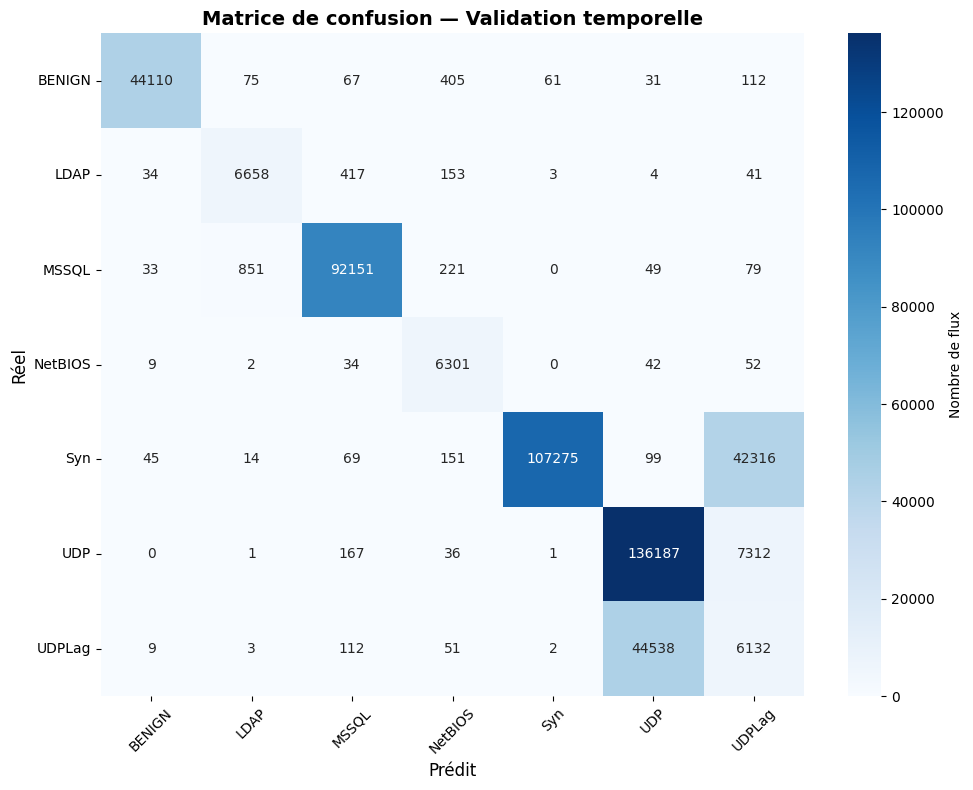

  -> matrice_confusion_graphique.png
ROC AUC (macro) : 0.9513


In [64]:
t0 = time()
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
duree_pred = time() - t0
print(f"Prediction : {duree_pred:.2f} s")
print("\nRapport détaillé :")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test_enc, y_pred)

print("\n" + "=" * 60)
print("MATRICE DE CONFUSION")
print("=" * 60)
print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_).to_string())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre de flux'})
plt.title('Matrice de confusion — Validation temporelle', fontsize=14, fontweight='bold')
plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(SORTIE / "matrice_confusion_graphique.png", dpi=300, bbox_inches="tight")
plt.show()
print("  -> matrice_confusion_graphique.png")
try:
    auc = roc_auc_score(y_test_enc, y_proba, multi_class="ovr", average="macro")
    print(f"ROC AUC (macro) : {auc:.4f}")
except Exception as e:
    auc = None
    print(f"ROC AUC non calculé : {e}")

In [65]:
importances = model.feature_importances_
idx_sorted = np.argsort(importances)[::-1][:15]

print("=" * 60)
print("TOP 15 FEATURES")
print("=" * 60)
for rank, idx in enumerate(idx_sorted, 1):
    print(f"{rank:2d}. {features[idx]:35s} : {importances[idx]:.4f}")

TOP 15 FEATURES
 1. Fwd Packet Length Std               : 0.1677
 2. Fwd Act Data Packets                : 0.1322
 3. ACK Flag Count                      : 0.1171
 4. Packet Length Min                   : 0.1104
 5. Inbound                             : 0.0746
 6. Idle Max                            : 0.0713
 7. URG Flag Count                      : 0.0612
 8. Fwd IAT Total                       : 0.0526
 9. Packet Length Variance              : 0.0287
10. Down/Up Ratio                       : 0.0156
11. CWE Flag Count                      : 0.0124
12. Flow Duration                       : 0.0106
13. Packet Length Mean                  : 0.0105
14. Bwd Packets/s                       : 0.0097
15. Fwd Packets/s                       : 0.0095


In [66]:
joblib.dump(model, SORTIE / "model_temporel_xgb.pkl")
joblib.dump(le, SORTIE / "label_encoder_temporel.pkl")

print("Modele et encoder sauvegardes")

Modele et encoder sauvegardes


In [67]:
X_test.to_parquet(SORTIE / "X_test_final.parquet", index=False)
y_test.to_frame("Label").to_parquet(SORTIE / "y_test_final.parquet", index=False)

print(f"X_test_final.parquet : {X_test.shape}")
print(f"y_test_final.parquet : {y_test.shape}")

X_test_final.parquet : (496515, 78)
y_test_final.parquet : (496515,)


CHARGEMENT
Modele : XGBClassifier
Classes : ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
X_test : (496515, 78)

Echantillon : 5,000 flux

CALCUL DES SHAP VALUES
shap_values.shape : (5000, 78, 7)
Toutes les matrices sont alignees !

GRAPHIQUE GLOBAL


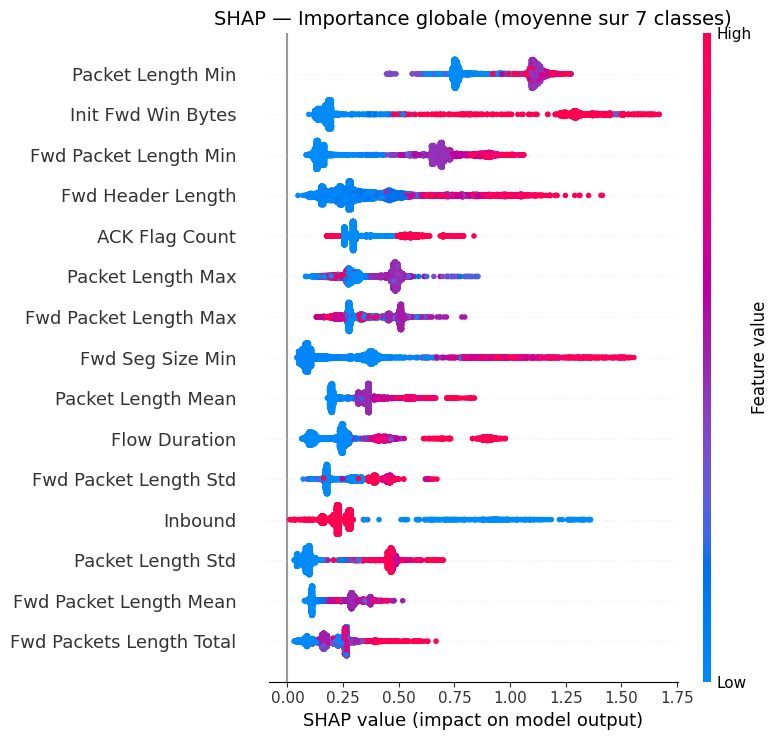

  -> shap_global.png

GRAPHIQUES PAR CLASSE


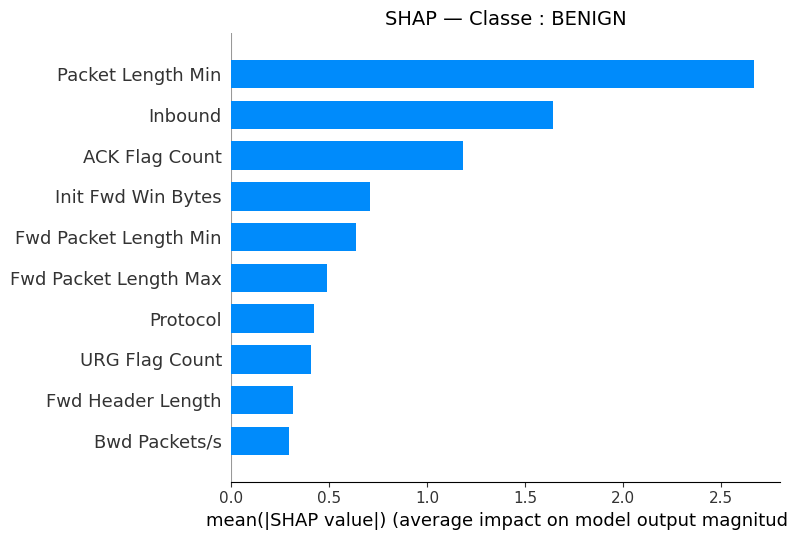

  -> shap_BENIGN.png


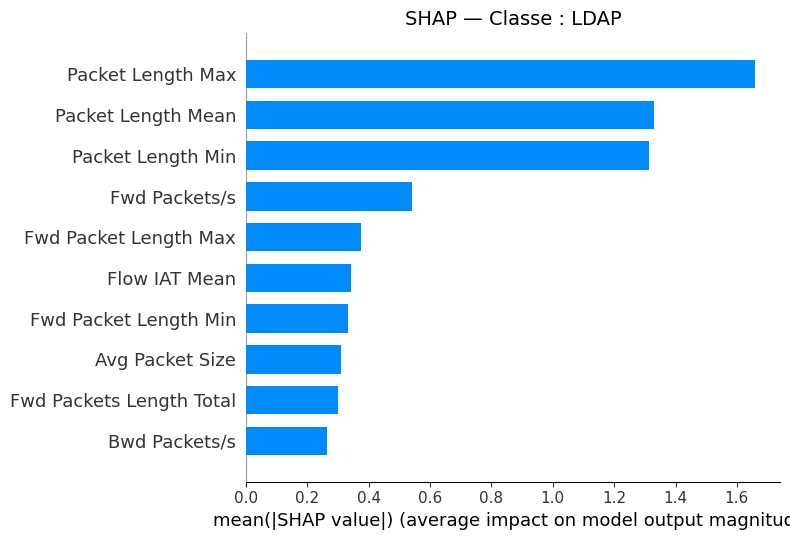

  -> shap_LDAP.png


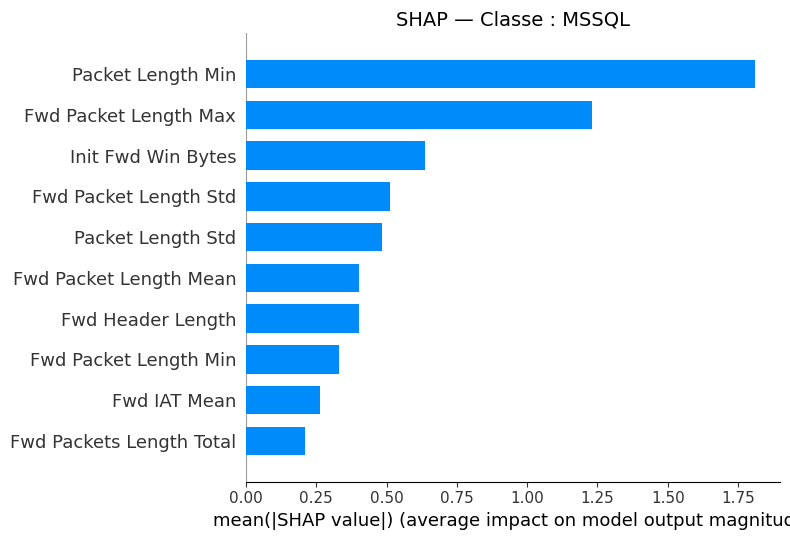

  -> shap_MSSQL.png


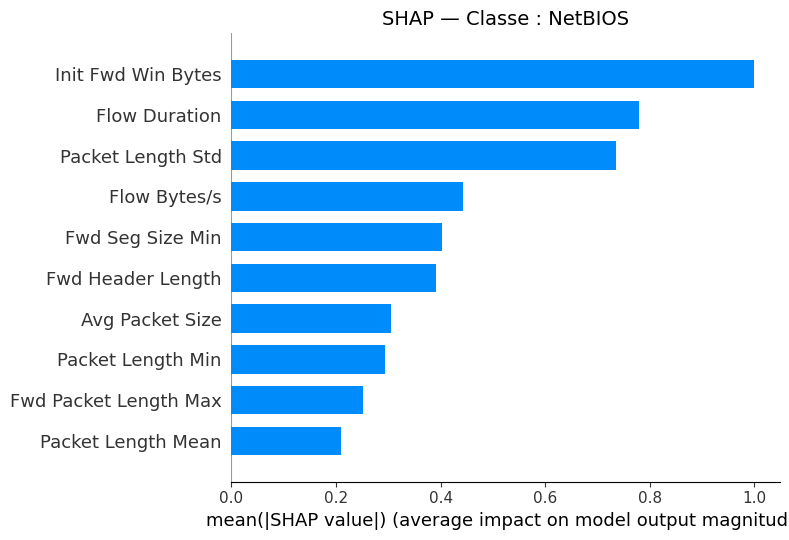

  -> shap_NetBIOS.png


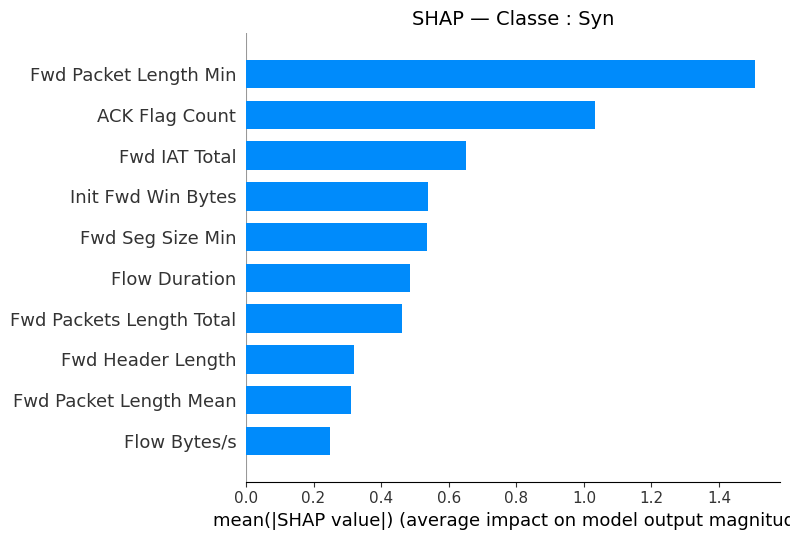

  -> shap_Syn.png


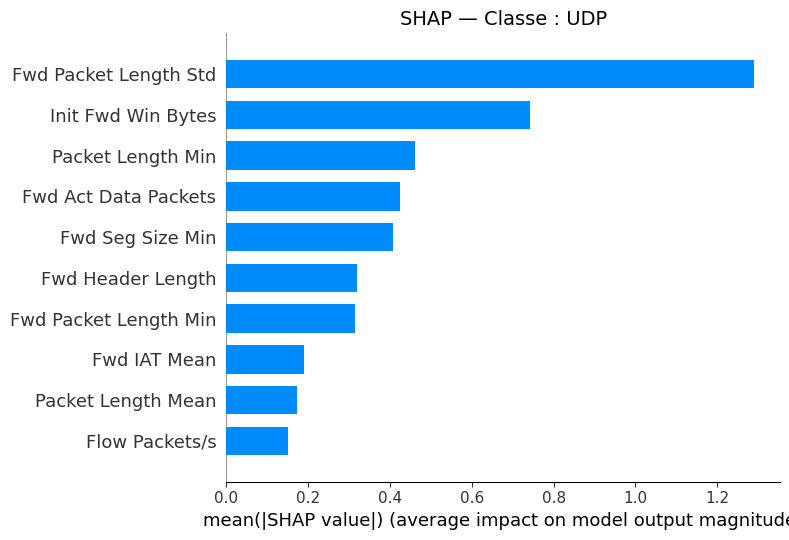

  -> shap_UDP.png


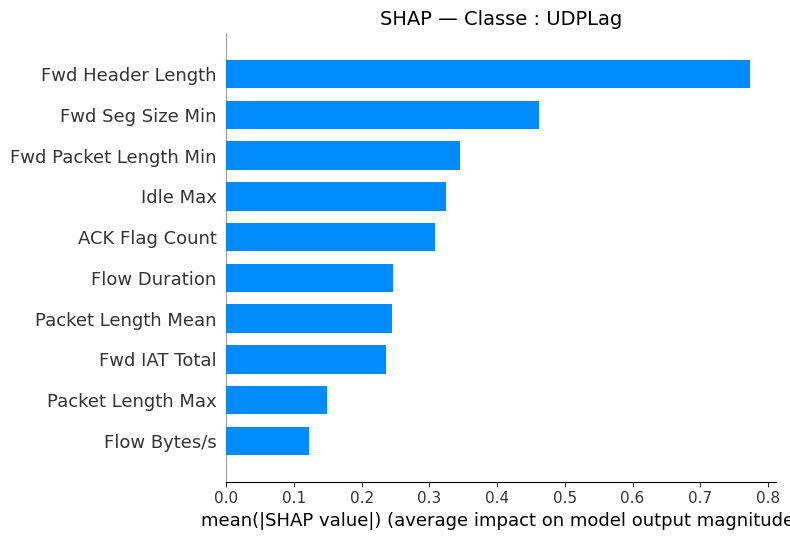

  -> shap_UDPLag.png

TOP 10 FEATURES PAR CLASSE

--- BENIGN ---
 1. Packet Length Min                   : 2.6700
 2. Inbound                             : 1.6445
 3. ACK Flag Count                      : 1.1854
 4. Init Fwd Win Bytes                  : 0.7061
 5. Fwd Packet Length Min               : 0.6378
 6. Fwd Packet Length Max               : 0.4896
 7. Protocol                            : 0.4194
 8. URG Flag Count                      : 0.4043
 9. Fwd Header Length                   : 0.3170
10. Bwd Packets/s                       : 0.2961

--- LDAP ---
 1. Packet Length Max                   : 1.6577
 2. Packet Length Mean                  : 1.3289
 3. Packet Length Min                   : 1.3126
 4. Fwd Packets/s                       : 0.5425
 5. Fwd Packet Length Max               : 0.3750
 6. Flow IAT Mean                       : 0.3410
 7. Fwd Packet Length Min               : 0.3325
 8. Avg Packet Size                     : 0.3096
 9. Fwd Packets Length Total           

In [68]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from pathlib import Path
import json

# ============================================================
# CONFIGURATION
# ============================================================
BASE = Path(r"E:\CIC-DDoS2019\echantillons")
SORTIE = BASE / "shap"
SORTIE.mkdir(parents=True, exist_ok=True)

SEED = 42
N_SAMPLE = 5000
CLASSES_COMMUNES = ["BENIGN", "LDAP", "MSSQL", "NetBIOS", "Syn", "UDP", "UDPLag"]

# ============================================================
# 1. CHARGEMENT DU MODELE
# ============================================================
print("=" * 60)
print("CHARGEMENT")
print("=" * 60)

model = joblib.load(BASE / "model_temporel_xgb.pkl")
le = joblib.load(BASE / "label_encoder_temporel.pkl")

print(f"Modele : {type(model).__name__}")
print(f"Classes : {list(le.classes_)}")

# ============================================================
# 2. PREPARATION DES DONNEES (MEME QUE L'ENTRAINEMENT)
# ============================================================
# Utiliser test_df (déjà en mémoire)
test = test_df.copy()
test = test[test["Label"].isin(CLASSES_COMMUNES)].reset_index(drop=True)

# Features (exclure Label et Day)
features = [c for c in test.columns if c not in ("Label", "Day")]
X_test = test[features].copy()

# Convertir les catégorielles en float32
for col in features:
    if X_test[col].dtype.name == 'category':
        X_test[col] = X_test[col].astype('float32')

print(f"X_test : {X_test.shape}")

# ============================================================
# 3. ECHANTILLON
# ============================================================
X_sample = X_test.sample(n=min(N_SAMPLE, len(X_test)), random_state=SEED)
print(f"\nEchantillon : {len(X_sample):,} flux")

# ============================================================
# 4. SHAP VALUES
# ============================================================
print("\n" + "=" * 60)
print("CALCUL DES SHAP VALUES")
print("=" * 60)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"shap_values.shape : {shap_values.shape}")

# ============================================================
# 5. EXTRACTION DES MATRICES PAR CLASSE
# ============================================================
n_samples = X_sample.shape[0]
n_features = X_sample.shape[1]
n_classes = len(le.classes_)

if shap_values.ndim == 3:
    s0, s1, s2 = shap_values.shape
    if s0 == n_samples and s1 == n_features and s2 == n_classes:
        sv_list = [shap_values[:, :, i] for i in range(n_classes)]
    elif s0 == n_classes and s1 == n_samples and s2 == n_features:
        sv_list = [shap_values[i] for i in range(n_classes)]
    elif s0 == n_samples and s1 == n_classes and s2 == n_features:
        sv_list = [shap_values[:, i, :] for i in range(n_classes)]
    else:
        raise ValueError(f"Format : {shap_values.shape}")
elif isinstance(shap_values, list):
    sv_list = [np.array(sv) for sv in shap_values]
else:
    sv_list = [shap_values] * n_classes

for i, sv in enumerate(sv_list):
    assert sv.shape == (n_samples, n_features)

print("Toutes les matrices sont alignees !")

# ============================================================
# 6. GRAPHIQUE GLOBAL — AFFICHER + ENREGISTRER
# ============================================================
print("\n" + "=" * 60)
print("GRAPHIQUE GLOBAL")
print("=" * 60)

shap_global = np.mean([np.abs(sv) for sv in sv_list], axis=0)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_global, X_sample, feature_names=features,
                  show=False, max_display=15)
plt.title("SHAP — Importance globale (moyenne sur 7 classes)", fontsize=14)
plt.tight_layout()
plt.savefig(SORTIE / "shap_global.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("  -> shap_global.png")

# ============================================================
# 7. GRAPHIQUES PAR CLASSE — AFFICHER + ENREGISTRER
# ============================================================
print("\n" + "=" * 60)
print("GRAPHIQUES PAR CLASSE")
print("=" * 60)

for i, classe in enumerate(le.classes_):
    sv = sv_list[i]
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_sample, feature_names=features,
                      plot_type="bar", show=False, max_display=10)
    plt.title(f"SHAP — Classe : {classe}", fontsize=14)
    plt.tight_layout()
    plt.savefig(SORTIE / f"shap_{classe}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  -> shap_{classe}.png")

# ============================================================
# 8. TOP FEATURES
# ============================================================
print("\n" + "=" * 60)
print("TOP 10 FEATURES PAR CLASSE")
print("=" * 60)

top_features = {}
for i, classe in enumerate(le.classes_):
    mean_abs = np.abs(sv_list[i]).mean(axis=0)
    idx_sorted = np.argsort(mean_abs)[::-1][:10]
    top_features[classe] = [
        {"feature": features[idx], "importance": float(mean_abs[idx])}
        for idx in idx_sorted
    ]
    print(f"\n--- {classe} ---")
    for rank, item in enumerate(top_features[classe], 1):
        print(f"{rank:2d}. {item['feature']:35s} : {item['importance']:.4f}")

print("\n" + "=" * 60)
print("TOP 15 FEATURES GLOBALES")
print("=" * 60)

all_shap = np.array(sv_list)
mean_global = np.abs(all_shap).mean(axis=(0, 1))
idx_global = np.argsort(mean_global)[::-1][:15]

global_features = []
for rank, idx in enumerate(idx_global, 1):
    global_features.append({
        "rank": rank,
        "feature": features[idx],
        "importance": float(mean_global[idx])
    })
    print(f"{rank:2d}. {features[idx]:35s} : {mean_global[idx]:.4f}")

# ============================================================
# 9. SAUVEGARDE
# ============================================================
resultats_shap = {
    "n_sample": len(X_sample),
    "n_features": len(features),
    "classes": list(le.classes_),
    "top_features_global": global_features,
    "top_features_par_classe": top_features,
}
with open(SORTIE / "shap_resultats.json", "w", encoding="utf-8") as f:
    json.dump(resultats_shap, f, indent=2, ensure_ascii=False)

rows = []
for classe, items in top_features.items():
    for rank, item in enumerate(items, 1):
        rows.append({"classe": classe, "rang": rank,
                     "feature": item["feature"],
                     "importance": item["importance"]})
pd.DataFrame(rows).to_csv(SORTIE / "shap_top_features.csv", index=False)

print(f"\n  -> shap_resultats.json")
print(f"  -> shap_top_features.csv")

print("\n" + "=" * 60)
print("TERMINE !")
print("=" * 60)

# Exporter le meilleur modèle pour le déploiement

In [ ]:

# 7. Sauvegarder
import joblib
#joblib.dump(meilleur_modele, 'meilleur_modele.pkl')
#print(f"\n Modèle sauvegardé : meilleur_modele.pkl")

In [ ]:
#model.save('modele_cnn_ddos.h5')
#print(" Modèle CNN sauvegardé !")